[2026-08-07 Fiddler](https://thefiddler.substack.com/p/how-lucky-can-a-baseball-team-get)
====================

Fiddler
-------
The probability that the A's (or the G-men) win $n$ games is ${162\choose n}/2^{162}$, so the probability
that the team with the better record wins $n$ games, where $n > 81$, is $2{162\choose n}/2^{162}$.

And the probability that both teams win 81 games is ${162\choose 81}/2^{162}$.

So, on average, the better team wins
$\left(81{162\choose81}+\sum_{n=82}^{162} 2n{162\choose n}\right)/2^{162} \approx 86.0699$.
[Simulations](20260807.go) agree, giving approximately 86.069.

In [1]:
p = (81*binomial(162,81)+sum(2*x*binomial(162,x), x, 82, 162))/2^162
p, numerical_approx(p)

(62895632625904371267814341812263929371665856338413/730750818665451459101842416358141509827966271488,
 86.0698763783376)

If 81-81 outcomes are ignored, then, on average, the better team wins
$\sum_{n=82}^{162} 2n{162\choose n}/\left(2^{162} - {162\choose81}\right) \approx 86.408$.

[Simulations](20260807.go) agree, giving approximately 86.41.

In [2]:
p = sum(2*x*binomial(162,x),x,82,162)/(2^162-binomial(162,81))
p, numerical_approx(p)

(59190816311901568187249235725009462296065267990528/685012345653071174156594193058703644697094810403,
 86.4083934946760)

Extra credit
------------
After two teams play each other, the possible distinct outcomes are

* probability of 2/32 that one team has 5 wins, one team has 0 wins, no teams are out of contention for the most wins
* probability of 10/32 that one team has 4 wins, one team has 1 win, no teams are out of contention for the most wins
* probability of 20/32 that one team has 3 wins, one team has 2 wins, no teams are out of contention for the most wins

I'll lump together all teams that are out of contention for the most wins to reduce the number of distinct outcomes,
since it doesn't matter how many wins they individually have.

After a third team plays both the first two teams, one possible outcome
is that one team has 10 wins, one team has 5 wins, one team has 0 wins, no teams are out of contention for the most
wins, which can happen 3 ways: the new team wins 10, the new team loses 10, the new team wins 5 from the winless team
and loses 5 to the undefeated team, making the probability of this outcome $2/32\cdot3/32^2 = 3/16384$.

Then, from all the 3-team outcomes, find the probabilities of the outcomes after a fourth team plays each
of the three teams.

This calculation becomes computationally unfeasible long before it gets to 30 teams, as there are 1111
distinct outcomes with 5 teams, and calculating the 10461 distinct outcomes with 6 teams takes minutes.
At least [simulations](20260807.go) indicate that the average number of wins the best team has should
be approximately 84.98.

One idea for speeding up this calculation would be to lump all teams with the same number of wins
together.  I doubt it would be enough to get to 30 teams, though.

In [3]:
def add_team(dist):
    new_dist = {}
    for team_wins, prob in dist.items():
        for new_prob, new_team_wins in dists_after_adding_team(0, team_wins):
            max_wins = max(new_team_wins)
            new_team_wins = list(new_team_wins)
            new_team_wins.sort(reverse=True)
            new_team_wins = tuple(new_team_wins)
            if new_team_wins in new_dist:
                new_dist[new_team_wins] += new_prob*prob
            else:
                new_dist[new_team_wins] = new_prob*prob
    return new_dist

def dists_after_adding_team(new_team_wins, other_teams):
    if len(other_teams) == 0:
        yield 1, (new_team_wins,)
        return
    for p, teams in dists_after_adding_team(new_team_wins, other_teams[1:]):
        yield p/32, teams + (other_teams[0]+5,)
    for p, teams in dists_after_adding_team(new_team_wins+1, other_teams[1:]):
        yield 5*p/32, teams + (other_teams[0]+4,)
    for p, teams in dists_after_adding_team(new_team_wins+2, other_teams[1:]):
        yield 10*p/32, teams + (other_teams[0]+3,)
    for p, teams in dists_after_adding_team(new_team_wins+3, other_teams[1:]):
        yield 10*p/32, teams + (other_teams[0]+2,)
    for p, teams in dists_after_adding_team(new_team_wins+4, other_teams[1:]):
        yield 5*p/32, teams + (other_teams[0]+1,)
    for p, teams in dists_after_adding_team(new_team_wins+5, other_teams[1:]):
        yield p/32, teams + (other_teams[0],)

In [4]:
dist = {(0,):1}
for n_teams in [2..6]:
    dist = add_team(dist)
    avg = [0 for i in range(n_teams)]
    for w, p in dist.items():
        for i in range(n_teams):
            avg[i] += p*w[i]
    navg = [numerical_approx(a) for a in avg]
    if n_teams < 4:
        print(n_teams, navg, avg, dist)
    else:
        print(n_teams, navg, avg, len(dist))

2 [3.43750000000000, 1.56250000000000] [55/16, 25/16] {(5, 0): 1/16, (4, 1): 5/16, (3, 2): 5/8}
3 [6.63513183593750, 5.00000000000000, 3.36486816406250] [54355/8192, 5, 27565/8192] {(10, 5, 0): 3/16384, (10, 4, 1): 15/16384, (10, 3, 2): 15/8192, (9, 5, 1): 45/8192, (9, 4, 2): 225/16384, (9, 3, 3): 75/8192, (9, 6, 0): 15/16384, (8, 5, 2): 705/16384, (8, 4, 3): 75/1024, (8, 6, 1): 225/16384, (8, 7, 0): 15/8192, (7, 5, 3): 645/4096, (7, 4, 4): 825/8192, (7, 6, 2): 75/1024, (7, 7, 1): 75/8192, (6, 5, 4): 1335/4096, (6, 6, 3): 825/8192, (5, 5, 5): 563/8192}
4 [9.79224331676960, 8.17094184458256, 6.82905815541744, 5.20775668323040] [657146325/67108864, 548342625/67108864, 458290335/67108864, 349486635/67108864] 131
5 [12.8964278449749, 11.2393501264086, 10.0000000000000, 8.76064987359143, 7.10357215502512] [226876357957185/17592186044416, 98862369221055/8796093022208, 10, 77059491223105/8796093022208, 124967362931135/17592186044416] 1111
6 [15.9569865522724, 14.2584191145991, 13.053869011463

### Revisiting
I suspect the average number of wins of each team can be approximately calculated by
finding an appropriate spread over a Gaussian distribution, but I don't know how to
justify it.

At least, from symmetry, I know that the sum of the least average number of wins
plus the most average number of wins should be half the number of games per team.
Same with the sum of the second least and and second most, etc.

Start with [simulations](20260807.go), which, for up to 6 teams, agrees with the above
calculation.

In [5]:
w_avg = [0 for i in [0..30]]
w_avg[2] = [1.562495,3.437505]
w_avg[3] = [3.364240,5.000316,6.635444]
w_avg[4] = [5.207151,6.828805,8.171531,9.792513]
w_avg[5] = [7.103015,8.760873,9.999918,11.239902,12.896291]
w_avg[6] = [9.043642,10.742291,11.946057,13.054018,14.257678,15.956314]
w_avg[7] = [11.015862,12.759134,13.955723,14.999796,16.044174,17.240646,18.984665]
w_avg[8] = [13.015190,14.805099,16.002620,17.016786,17.983024,18.996959,20.194715,21.985608]
w_avg[9] = [15.037352,16.874396,18.080718,19.078146,19.999969,20.921987,21.920191,23.125710,24.961532]
w_avg[10] = [17.079268,18.960826,20.179350,21.170358,22.066065,22.934399,23.830115,24.820544,26.038161,27.920914]
w_avg[11] = [19.137508,21.064895,22.296806,23.285653,24.165014,25.000074,25.835228,26.714786,27.703370,28.934542,30.862122]
w_avg[12] = [21.212968,23.182434,24.429138,25.419711,26.289623,27.101971,27.897769,28.710886,29.580777,30.570709,31.816259,33.787754]
w_avg[13] = [23.297146,25.310846,26.574264,27.567911,28.432994,29.230944,30.000621,30.769457,31.567294,32.431811,33.426444,34.688252,36.702016]
w_avg[14] = [25.397043,27.450893,28.730843,29.730383,30.592649,31.380256,32.130505,32.869030,33.619325,34.407069,35.270375,36.270243,37.548033,39.603354]
w_avg[15] = [27.507085,29.601566,30.896942,31.902873,32.764829,33.546617,34.283003,34.999880,35.716523,36.453592,37.234989,38.096711,39.104141,40.398317,42.492931]
w_avg[16] = [29.626899,31.761072,33.072734,34.085360,34.949572,35.726655,36.453959,37.154632,37.845797,38.545732,39.272648,40.050022,40.913305,41.927475,43.240322,45.373817]
w_avg[17] = [31.755632,33.926706,35.254558,36.276001,37.141338,37.916535,38.636565,39.325189,39.999232,40.673914,41.362412,42.082649,42.857596,43.723948,44.745944,46.073855,48.247926]
w_avg[18] = [33.890842,36.101636,37.447204,38.476536,39.345614,40.118846,40.834494,41.513885,42.173045,42.826843,43.485922,44.165073,44.880414,45.654764,46.523392,47.553403,48.899167,51.108921]
w_avg[19] = [36.034575,38.282244,39.643678,40.682028,41.554814,42.329349,43.041184,43.713591,44.361968,45.000011,45.637467,46.286313,46.958830,47.670730,48.444872,49.317737,50.356816,51.718868,53.964925]
w_avg[20] = [38.186451,40.469547,41.846803,42.895236,43.772337,44.546387,45.256713,45.924138,46.564869,47.190420,47.810544,48.435923,49.076487,49.743472,50.453062,51.227989,52.105231,53.152633,54.530121,56.811635]
w_avg[21] = [40.346849,42.663092,44.055665,45.113673,45.994588,46.771816,47.480493,48.143519,48.777324,49.393511,50.000349,50.606690,51.222720,51.855685,52.519528,53.228288,54.005428,54.886970,55.943361,57.336661,59.653788]
w_avg[22] = [42.511159,44.862617,46.271949,47.337451,48.224419,49.002604,49.711141,50.371863,50.999973,51.607749,52.203593,52.795454,53.391841,53.999839,54.628353,55.288549,55.997283,56.776013,57.662905,58.728141,60.137801,62.489303]
w_avg[23] = [44.681964,47.065406,48.491919,49.566079,50.458554,51.239814,51.948309,52.606871,53.231440,53.832803,54.419908,55.000335,55.579946,56.167661,56.769247,57.393721,58.052791,58.761192,59.541756,60.432465,61.507392,62.932381,65.318044]
w_avg[24] = [46.857964,49.273394,50.716434,51.800113,52.697634,53.482249,54.191222,54.848455,55.469217,56.065547,56.645879,57.216078,57.783880,58.353778,58.933453,59.529574,60.151507,60.809239,61.518604,62.302946,63.200312,64.284466,65.725954,68.142100]
w_avg[25] = [49.039836,51.489905,52.946143,54.038747,54.941223,55.728303,56.439011,57.095938,57.715601,58.307903,58.881440,59.443278,59.999512,60.555969,61.118314,61.692446,62.284781,62.904033,63.561112,64.271226,65.058657,65.962128,67.053647,68.510546,70.960297]
w_avg[26] = [51.226919,53.707221,55.177673,56.279590,57.188100,57.978742,58.690552,59.348137,59.965807,60.554880,61.123881,61.679466,62.227519,62.772767,63.320896,63.876615,64.445343,65.034782,65.652251,66.309219,67.020933,67.811376,68.720358,69.821368,71.293295,73.772308]
w_avg[27] = [53.417811,55.928609,57.416572,58.527231,59.440904,60.234775,60.948339,61.605617,62.221598,62.808390,63.373244,63.923143,64.463609,65.000092,65.536019,66.076335,66.626647,67.191765,67.778440,68.394586,69.052186,69.766104,70.559427,71.473461,72.584530,74.070498,76.580068]
w_avg[28] = [55.613276,58.154035,59.655597,60.775719,61.696266,62.493996,63.209411,63.866996,64.482505,65.067281,65.628889,66.173913,66.708297,67.236782,67.762626,68.290779,68.825260,69.370819,69.932526,70.517298,71.132948,71.791194,72.507179,73.304905,74.224840,75.344829,76.846646,79.385186]
w_avg[29] = [57.815053,60.383496,61.900059,63.028484,63.955078,64.757023,65.474970,66.133318,66.748485,67.331645,67.891224,68.432766,68.961808,69.482932,70.000479,70.517347,71.038244,71.567236,72.108901,72.668244,73.251314,73.866017,74.524988,75.242920,76.044535,76.971451,78.099810,79.616223,82.185950]
w_avg[30] = [60.016584,62.617537,64.147875,65.284654,66.216151,67.022225,67.742541,68.402117,69.018167,69.600228,70.157411,70.695602,71.220552,71.735782,72.245962,72.754503,73.264378,73.779635,74.304258,74.842735,75.399917,75.982260,76.597202,77.257345,77.977409,78.783042,79.714809,80.853016,82.382552,84.983550]

In [6]:
pts = []
for nteams in [2..30]:
    mu = (nteams-1)*5/2
    sigma2 = (nteams-1)*5/4
    s = numerical_approx(sum([e^(-(x-mu)^2/(2*sigma2))/sqrt(2*pi*sigma2) for x in w_avg[nteams]]))
    pts.append((nteams,s))
    print(nteams,s)

2 0.502113354847448
3 0.547846032763232
4 0.592425440701087
5 0.638609868777732
6 0.683406178287053
7 0.726162511208007
8 0.767034435602555
9 0.806298721264119
10 0.843842217379790
11 0.879983611093374
12 0.914863802325293
13 0.948360121320146
14 0.980906961277909
15 1.01243873198418
16 1.04312902250773
17 1.07272585845203
18 1.10188815266677
19 1.13011000511613
20 1.15774625208469
21 1.18473520381595
22 1.21117243938806
23 1.23703783262521
24 1.26234822968175
25 1.28727684507196
26 1.31156287494155
27 1.33554797593808
28 1.35899630610022
29 1.38218835030897
30 1.40486134456533


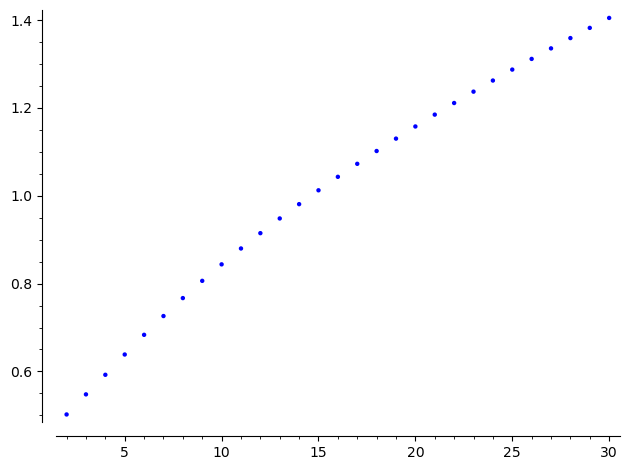

In [7]:
points(pts)

It's not the case that the appropriate spread of wins leads to constant sum of the
Gaussian probability densities when varying the number of teams.  Not that I have
any reason to say that it does, and it makes sense that it increases, since I'd
expect the 3rd and 4th teams out of 6 to be closer to the mean than the 2nd and 3rd
out of 4.